#### STEP 1: IMPORTS & SETUP

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import time
import os  # Added for directory creation
import pickle  # Added for model export
import json  # Added for metadata export
from datetime import datetime  # Added for timestamps
from collections import defaultdict

# Scikit-learn models
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier
from sklearn.neural_network import MLPClassifier  # Added for Neural Network

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, auc
)

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"✓ Random state set to: {RANDOM_STATE}")

✓ Random state set to: 42


### STEP 2: LOAD & SPLIT DATA

In [2]:
# Load dataset
data_path = 'datasets/training/final_dataset.csv'


email_df = pd.read_csv(data_path)

# Display dataset info
print(f"\nDataset Shape: {email_df.shape}")
print(f"Total Samples: {email_df.shape[0]:,}")
print(f"Total Features: {email_df.shape[1] - 1:,} (excluding label)")

# Check for missing values
missing_count = email_df.isnull().sum().sum()
print(f"Missing Values: {missing_count}")


Dataset Shape: (99115, 7016)
Total Samples: 99,115
Total Features: 7,015 (excluding label)
Missing Values: 0


In [3]:
# Separate features and labels
X = email_df.drop('label', axis=1)
y = email_df['label']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")

# Display class distribution
print("\n" + "-" * 80)
print("CLASS DISTRIBUTION")
print("-" * 80)

class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print(f"\nClass 0 (Legitimate): {class_counts[0]:,} ({class_percentages[0]:.2f}%)")
print(f"Class 1 (Phishing):   {class_counts[1]:,} ({class_percentages[1]:.2f}%)")

# Check for class imbalance
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("⚠ Dataset is imbalanced - will use appropriate metrics (F1, ROC-AUC)")
else:
    print("✓ Dataset is balanced")



Features (X) shape: (99115, 7015)
Labels (y) shape: (99115,)

--------------------------------------------------------------------------------
CLASS DISTRIBUTION
--------------------------------------------------------------------------------

Class 0 (Legitimate): 42,716 (43.10%)
Class 1 (Phishing):   56,399 (56.90%)

Imbalance Ratio: 1.32:1
✓ Dataset is balanced


In [4]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Maintain class distribution in splits
)

print(f"\nTraining Set:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Class distribution: {y_train.value_counts().to_dict()}")

print(f"\nTest Set:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Class distribution: {y_test.value_counts().to_dict()}")



Training Set:
X_train shape: (79292, 7015)
y_train shape: (79292,)
Class distribution: {1: 45119, 0: 34173}

Test Set:
X_test shape: (19823, 7015)
y_test shape: (19823,)
Class distribution: {1: 11280, 0: 8543}


# STEP 3: DEFINE TRAINING FUNCTION

In [5]:
def train_models(X_train, y_train):
    """
    Train all four models and return them with training times.

    Parameters:
    -----------
    X_train : DataFrame or array
        Training features
    y_train : Series or array
        Training labels

    Returns:
    --------
    models : dict
        Dictionary containing trained models
    training_times : dict
        Dictionary containing training times for each model
    """

    print("=" * 80)
    print("TRAINING MODELS")
    print("=" * 80)

    models = {}
    training_times = {}

    # Model 1: SGDClassifier with hinge loss (Linear SVM)
    print("\n[1/4] Training SGDClassifier (loss='hinge')...")
    start_time = time.time()

    sgd_hinge = SGDClassifier(
        loss='hinge',
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    sgd_hinge.fit(X_train, y_train)

    training_times['SGD_Hinge'] = time.time() - start_time
    models['SGD_Hinge'] = sgd_hinge
    print(f"      Completed in {training_times['SGD_Hinge']:.2f} seconds")

    # Model 2: Passive Aggressive Classifier
    print("\n[2/4] Training Passive Aggressive Classifier...")
    start_time = time.time()

    pac = PassiveAggressiveClassifier(
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    pac.fit(X_train, y_train)

    training_times['PAC'] = time.time() - start_time
    models['PAC'] = pac
    print(f"      Completed in {training_times['PAC']:.2f} seconds")

    # Model 3: SGDClassifier with log_loss (Logistic Regression)
    print("\n[3/4] Training SGDClassifier (loss='log_loss')...")
    start_time = time.time()

    sgd_log = SGDClassifier(
        loss='log_loss',
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    sgd_log.fit(X_train, y_train)

    training_times['SGD_LogLoss'] = time.time() - start_time
    models['SGD_LogLoss'] = sgd_log
    print(f"      Completed in {training_times['SGD_LogLoss']:.2f} seconds")

    # Model 4: MLPClassifier (Neural Network)
    print("\n[4/4] Training MLPClassifier (Neural Network)...")
    print("      This may take 15-30 minutes...")
    start_time = time.time()

    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size=256,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        warm_start=True,
        verbose=False,  # Set to False to avoid cluttering output
        random_state=RANDOM_STATE
    )
    mlp.fit(X_train, y_train)

    training_times['MLP_Classifier'] = time.time() - start_time
    models['MLP_Classifier'] = mlp
    print(f"      Completed in {training_times['MLP_Classifier']/60:.2f} minutes ({training_times['MLP_Classifier']:.2f} seconds)")
    print(f"      Iterations: {mlp.n_iter_}, Loss: {mlp.loss_:.6f}")

    print("\n" + "=" * 80)
    print("TRAINING COMPLETE")
    print("=" * 80)

    # Display training times summary
    print("\nTraining Times Summary:")
    for model_name, train_time in training_times.items():
        if train_time < 60:
            print(f"  {model_name:20s}: {train_time:.2f} seconds")
        else:
            print(f"  {model_name:20s}: {train_time/60:.2f} minutes ({train_time:.0f} seconds)")

    total_time = sum(training_times.values())
    if total_time < 60:
        print(f"  {'Total':20s}: {total_time:.2f} seconds")
    else:
        print(f"  {'Total':20s}: {total_time/60:.2f} minutes ({total_time:.0f} seconds)")

    return models, training_times

### STEP 4: CORE PERFORMANCE METRICS

In [6]:
def evaluate_core_metrics(models, X_test, y_test):
    """
    Evaluate core performance metrics for all models.

    Parameters:
    -----------
    models : dict
        Dictionary of trained models
    X_test : DataFrame or array
        Test features
    y_test : Series or array
        Test labels

    Returns:
    --------
    results_df : DataFrame
        DataFrame containing all core metrics
    """

    print("\n" + "=" * 80)
    print("EVALUATING CORE PERFORMANCE METRICS")
    print("=" * 80)

    results = []

    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}...")

        # Make predictions
        y_pred = model.predict(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)

        results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'F2_Score': f2
        })

        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1 Score:  {f1:.4f}")
        print(f"  F2 Score:  {f2:.4f}")

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 80)
    print("CORE METRICS SUMMARY")
    print("=" * 80)
    print(results_df.to_string(index=False))

    return results_df


def plot_core_metrics(results_df):
    """
    Plot bar graphs for all core metrics.

    Parameters:
    -----------
    results_df : DataFrame
        DataFrame containing core metrics
    """

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'F2_Score']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']  # Updated for 4 models

    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]

        models = results_df['Model'].values
        values = results_df[metric].values

        bars = ax.bar(models, values, color=colors[:len(models)], alpha=0.8, edgecolor='black')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.4f}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.set_ylabel(label, fontsize=12, fontweight='bold')
        ax.set_title(f'{label} Comparison', fontsize=14, fontweight='bold')
        ax.set_ylim([0, 1.1])
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(models, rotation=15, ha='right')

    # Remove extra subplot
    fig.delaxes(axes[5])

    plt.tight_layout()
    plt.suptitle('Core Performance Metrics Comparison',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    print("\nCore metrics visualization complete.")


def plot_metrics_heatmap(results_df):
    """
    Plot heatmap of all core metrics for easy comparison.

    Parameters:
    -----------
    results_df : DataFrame
        DataFrame containing core metrics
    """

    plt.figure(figsize=(10, 6))

    # Prepare data for heatmap
    heatmap_data = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall',
                                                    'F1_Score', 'F2_Score']]
    heatmap_data.columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score']

    # Create heatmap
    sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
                cbar_kws={'label': 'Score'}, linewidths=2, linecolor='white',
                vmin=0, vmax=1)

    plt.title('Core Metrics Heatmap', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Model', fontsize=12, fontweight='bold')
    plt.xlabel('Metric', fontsize=12, fontweight='bold')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\nCore metrics heatmap complete.")

#### STEP 5: BIAS & HALLUCINATION DETECTION

In [15]:
def evaluate_bias_metrics(models, X_test, y_test):
    """
    Evaluate bias and discrimination metrics for all models.

    Parameters:
    -----------
    models : dict
        Dictionary of trained models
    X_test : DataFrame or array
        Test features
    y_test : Series or array
        Test labels

    Returns:
    --------
    results_df : DataFrame
        DataFrame containing bias metrics
    predictions : dict
        Dictionary containing predictions and probabilities
    """

    print("\n" + "=" * 80)
    print("EVALUATING BIAS & DISCRIMINATION METRICS")
    print("=" * 80)

    results = []
    predictions = {}

    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}...")

        # Make predictions
        y_pred = model.predict(X_test)

        # Get prediction probabilities (for models that support it)
        if hasattr(model, 'decision_function'):
            y_score = model.decision_function(X_test)
        elif hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = y_pred

        # Calculate ROC-AUC
        roc_auc = roc_auc_score(y_test, y_score)

        # Calculate Precision-Recall AUC
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_score)
        pr_auc = auc(recall_curve, precision_curve)

        # Store predictions
        predictions[model_name] = {
            'y_pred': y_pred,
            'y_score': y_score,
            'y_test': y_test
        }

        results.append({
            'Model': model_name,
            'ROC_AUC': roc_auc,
            'PR_AUC': pr_auc
        })

        print(f"  ROC-AUC: {roc_auc:.4f}")
        print(f"  PR-AUC:  {pr_auc:.4f}")

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 80)
    print("BIAS METRICS SUMMARY")
    print("=" * 80)
    print(results_df.to_string(index=False))

    return results_df, predictions


def plot_roc_curves(predictions):
    """
    Plot ROC curves for all models.

    Parameters:
    -----------
    predictions : dict
        Dictionary containing predictions and scores
    """

    plt.figure(figsize=(10, 8))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']  # 4 colors for 4 models

    for idx, (model_name, pred_data) in enumerate(predictions.items()):
        y_test = pred_data['y_test']
        y_score = pred_data['y_score']

        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = roc_auc_score(y_test, y_score)

        plt.plot(fpr, tpr, color=colors[idx], lw=2,
                label=f'{model_name} (AUC = {roc_auc:.4f})')

    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5000)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nROC curves visualization complete.")


def plot_confusion_matrices(predictions):
    """
    Plot confusion matrices for all models.

    Parameters:
    -----------
    predictions : dict
        Dictionary containing predictions
    """

    n_models = len(predictions)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))

    # Handle case where there's only 1 model
    if n_models == 1:
        axes = [axes]

    for idx, (model_name, pred_data) in enumerate(predictions.items()):
        y_test = pred_data['y_test']
        y_pred = pred_data['y_pred']

        # Calculate confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        # Plot
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   cbar=False, ax=axes[idx],
                   xticklabels=['Legitimate', 'Phishing'],
                   yticklabels=['Legitimate', 'Phishing'])

        axes[idx].set_title(f'{model_name}\nConfusion Matrix',
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\nConfusion matrices visualization complete.")


def plot_precision_recall_curves(predictions):
    """
    Plot Precision-Recall curves for all models.

    Parameters:
    -----------
    predictions : dict
        Dictionary containing predictions and scores
    """

    plt.figure(figsize=(10, 8))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']  # 4 colors for 4 models

    for idx, (model_name, pred_data) in enumerate(predictions.items()):
        y_test = pred_data['y_test']
        y_score = pred_data['y_score']

        # Calculate PR curve
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        pr_auc = auc(recall, precision)

        plt.plot(recall, precision, color=colors[idx], lw=2,
                label=f'{model_name} (AUC = {pr_auc:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12, fontweight='bold')
    plt.ylabel('Precision', fontsize=12, fontweight='bold')
    plt.title('Precision-Recall Curves Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nPrecision-Recall curves visualization complete.")


def calculate_classwise_metrics(predictions):
    """
    Calculate per-class metrics for all models.

    Parameters:
    -----------
    predictions : dict
        Dictionary containing predictions

    Returns:
    --------
    classwise_df : DataFrame
        DataFrame containing per-class metrics
    """

    print("\n" + "=" * 80)
    print("CLASS-WISE METRICS")
    print("=" * 80)

    results = []

    for model_name, pred_data in predictions.items():
        y_test = pred_data['y_test']
        y_pred = pred_data['y_pred']

        print(f"\n{model_name}:")
        print("-" * 40)

        # Get classification report
        report = classification_report(y_test, y_pred,
                                      target_names=['Legitimate', 'Phishing'],
                                      output_dict=True)

        # Extract metrics for each class
        for class_name in ['Legitimate', 'Phishing']:
            results.append({
                'Model': model_name,
                'Class': class_name,
                'Precision': report[class_name]['precision'],
                'Recall': report[class_name]['recall'],
                'F1_Score': report[class_name]['f1-score'],
                'Support': report[class_name]['support']
            })

        # Print report
        print(classification_report(y_test, y_pred,
                                   target_names=['Legitimate', 'Phishing']))

    classwise_df = pd.DataFrame(results)

    return classwise_df

#### STEP 6: ROBUSTNESS CHECKS

In [8]:
def evaluate_robustness(models, X_train, y_train, X_test, y_test):
    """
    Evaluate model robustness using cross-validation and overfitting checks.

    Parameters:
    -----------
    models : dict
        Dictionary of trained models
    X_train : DataFrame or array
        Training features
    y_train : Series or array
        Training labels
    X_test : DataFrame or array
        Test features
    y_test : Series or array
        Test labels

    Returns:
    --------
    results_df : DataFrame
        DataFrame containing robustness metrics
    """

    print("\n" + "=" * 80)
    print("EVALUATING ROBUSTNESS & STABILITY")
    print("=" * 80)

    results = []

    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}...")

        # Cross-validation scores (5-fold)
        cv_scores = cross_val_score(model, X_train, y_train,
                                    cv=5, scoring='f1', n_jobs=-1)
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        print(f"  Cross-Validation (5-fold):")
        print(f"    Mean F1:  {cv_mean:.4f}")
        print(f"    Std Dev:  {cv_std:.4f}")
        print(f"    Scores:   {[f'{score:.4f}' for score in cv_scores]}")

        # Training performance
        y_train_pred = model.predict(X_train)
        train_f1 = f1_score(y_train, y_train_pred)

        # Test performance
        y_test_pred = model.predict(X_test)
        test_f1 = f1_score(y_test, y_test_pred)

        # Calculate performance gap (overfitting indicator)
        performance_gap = train_f1 - test_f1

        print(f"  Training F1:      {train_f1:.4f}")
        print(f"  Test F1:          {test_f1:.4f}")
        print(f"  Performance Gap:  {performance_gap:.4f}")

        if performance_gap > 0.05:
            print(f"    Warning: Possible overfitting detected")
        else:
            print(f"    Model generalizes well")

        # Stability score (inverse of std dev)
        stability_score = 1 - cv_std

        results.append({
            'Model': model_name,
            'CV_Mean_F1': cv_mean,
            'CV_Std_Dev': cv_std,
            'Train_F1': train_f1,
            'Test_F1': test_f1,
            'Performance_Gap': performance_gap,
            'Stability_Score': stability_score
        })

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 80)
    print("ROBUSTNESS SUMMARY")
    print("=" * 80)
    print(results_df.to_string(index=False))

    return results_df


def plot_robustness_comparison(robustness_df):
    """
    Plot robustness metrics comparison.

    Parameters:
    -----------
    robustness_df : DataFrame
        DataFrame containing robustness metrics
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    models = robustness_df['Model'].values
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    # Plot 1: CV Mean F1 with error bars
    ax1 = axes[0]
    cv_means = robustness_df['CV_Mean_F1'].values
    cv_stds = robustness_df['CV_Std_Dev'].values

    bars = ax1.bar(models, cv_means, color=colors, alpha=0.8,
                   edgecolor='black', yerr=cv_stds, capsize=10)

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax1.set_ylabel('Cross-Validation F1 Score', fontsize=11, fontweight='bold')
    ax1.set_title('CV Performance (Mean ± Std)', fontsize=12, fontweight='bold')
    ax1.set_ylim([0, 1.1])
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xticklabels(models, rotation=15, ha='right')

    # Plot 2: Train vs Test F1
    ax2 = axes[1]
    x = np.arange(len(models))
    width = 0.35

    bars1 = ax2.bar(x - width/2, robustness_df['Train_F1'].values,
                    width, label='Train F1', color='#2ca02c', alpha=0.8, edgecolor='black')
    bars2 = ax2.bar(x + width/2, robustness_df['Test_F1'].values,
                    width, label='Test F1', color='#d62728', alpha=0.8, edgecolor='black')

    ax2.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
    ax2.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, rotation=15, ha='right')
    ax2.legend()
    ax2.set_ylim([0, 1.1])
    ax2.grid(axis='y', alpha=0.3)

    # Plot 3: Stability Score
    ax3 = axes[2]
    stability_scores = robustness_df['Stability_Score'].values

    bars = ax3.bar(models, stability_scores, color=colors, alpha=0.8, edgecolor='black')

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax3.set_ylabel('Stability Score', fontsize=11, fontweight='bold')
    ax3.set_title('Model Stability (1 - CV Std)', fontsize=12, fontweight='bold')
    ax3.set_ylim([0, 1.1])
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_xticklabels(models, rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

    print("\nRobustness comparison visualization complete.")

#### STEP 7: FINAL SCORING & WINNER SELECTION

In [19]:
def calculate_final_scores(core_df, bias_df, robustness_df):
    """
    Calculate final weighted scores for all models.

    Weighting scheme:
    - Recall: 35% (most critical - catching phishing emails)
    - F1 Score: 25% (balance between precision and recall)
    - ROC-AUC: 20% (discrimination ability)
    - Precision: 10% (minimize false alarms)
    - Stability: 10% (consistency across different data)

    Parameters:
    -----------
    core_df : DataFrame
        Core performance metrics
    bias_df : DataFrame
        Bias/discrimination metrics
    robustness_df : DataFrame
        Robustness metrics

    Returns:
    --------
    final_df : DataFrame
        DataFrame with final scores and rankings
    """

    print("\n" + "=" * 80)
    print("CALCULATING FINAL WEIGHTED SCORES")
    print("=" * 80)

    # Merge all metrics
    final_df = core_df[['Model', 'Recall', 'F1_Score', 'Precision']].copy()
    final_df = final_df.merge(bias_df[['Model', 'ROC_AUC']], on='Model')
    final_df = final_df.merge(robustness_df[['Model', 'Stability_Score']], on='Model')

    # Define weights
    weights = {
        'Recall': 0.35,
        'F1_Score': 0.25,
        'ROC_AUC': 0.20,
        'Precision': 0.10,
        'Stability_Score': 0.10
    }

    print("\nWeighting Scheme:")
    print("-" * 40)
    for metric, weight in weights.items():
        print(f"  {metric:20s}: {weight*100:.0f}%")

    # Calculate weighted score
    final_df['Final_Score'] = (
        final_df['Recall'] * weights['Recall'] +
        final_df['F1_Score'] * weights['F1_Score'] +
        final_df['ROC_AUC'] * weights['ROC_AUC'] +
        final_df['Precision'] * weights['Precision'] +
        final_df['Stability_Score'] * weights['Stability_Score']
    )

    # Add ranking
    final_df['Rank'] = final_df['Final_Score'].rank(ascending=False).astype(int)
    final_df = final_df.sort_values('Rank')

    print("\n" + "=" * 80)
    print("FINAL SCORES & RANKINGS")
    print("=" * 80)
    print(final_df.to_string(index=False))

    return final_df


def declare_winner(final_df, core_df, bias_df, robustness_df):
    """
    Declare the winner and provide detailed analysis.

    Parameters:
    -----------
    final_df : DataFrame
        Final scores dataframe
    core_df : DataFrame
        Core metrics dataframe
    bias_df : DataFrame
        Bias metrics dataframe
    robustness_df : DataFrame
        Robustness metrics dataframe
    """

    winner = final_df.iloc[0]
    winner_name = winner['Model']

    print("\n" + "=" * 80)
    print("WINNER DECLARATION")
    print("=" * 80)

    print(f"\n{'*' * 80}")
    print(f"  WINNER: {winner_name}")
    print(f"  Final Score: {winner['Final_Score']:.4f}")
    print(f"{'*' * 80}")

    # Get detailed metrics for winner
    winner_core = core_df[core_df['Model'] == winner_name].iloc[0]
    winner_bias = bias_df[bias_df['Model'] == winner_name].iloc[0]
    winner_robust = robustness_df[robustness_df['Model'] == winner_name].iloc[0]

    print(f"\n{winner_name} Performance Summary:")
    print("-" * 80)

    print("\nCore Metrics:")
    print(f"  Accuracy:  {winner_core['Accuracy']:.4f}")
    print(f"  Precision: {winner_core['Precision']:.4f}")
    print(f"  Recall:    {winner_core['Recall']:.4f}")
    print(f"  F1 Score:  {winner_core['F1_Score']:.4f}")
    print(f"  F2 Score:  {winner_core['F2_Score']:.4f}")

    print("\nDiscrimination Metrics:")
    print(f"  ROC-AUC: {winner_bias['ROC_AUC']:.4f}")
    print(f"  PR-AUC:  {winner_bias['PR_AUC']:.4f}")

    print("\nRobustness Metrics:")
    print(f"  CV Mean F1:       {winner_robust['CV_Mean_F1']:.4f}")
    print(f"  CV Std Dev:       {winner_robust['CV_Std_Dev']:.4f}")
    print(f"  Performance Gap:  {winner_robust['Performance_Gap']:.4f}")
    print(f"  Stability Score:  {winner_robust['Stability_Score']:.4f}")

    # Key strengths analysis
    print("\nKey Strengths:")
    print("-" * 40)

    strengths = []

    if winner_core['Recall'] >= 0.95:
        strengths.append("Excellent recall - catches most phishing emails")
    elif winner_core['Recall'] >= 0.90:
        strengths.append("High recall - catches majority of phishing emails")

    if winner_core['Precision'] >= 0.95:
        strengths.append("Excellent precision - minimal false alarms")
    elif winner_core['Precision'] >= 0.90:
        strengths.append("High precision - few false alarms")

    if winner_core['F1_Score'] >= 0.95:
        strengths.append("Outstanding balance between precision and recall")
    elif winner_core['F1_Score'] >= 0.90:
        strengths.append("Strong balance between precision and recall")

    if winner_robust['CV_Std_Dev'] < 0.02:
        strengths.append("Very stable performance across different data splits")
    elif winner_robust['CV_Std_Dev'] < 0.05:
        strengths.append("Stable performance across different data splits")

    if winner_robust['Performance_Gap'] < 0.03:
        strengths.append("Excellent generalization - no overfitting")
    elif winner_robust['Performance_Gap'] < 0.05:
        strengths.append("Good generalization - minimal overfitting")

    for i, strength in enumerate(strengths, 1):
        print(f"  {i}. {strength}")

    # Recommendation
    print("\n" + "=" * 80)
    print("RECOMMENDATION")
    print("=" * 80)
    print(f"\n{winner_name} is recommended for phishing email detection based on:")
    print("  - Comprehensive performance across all evaluation metrics")
    print("  - Strong balance between catching phishing and avoiding false alarms")
    print("  - Consistent and stable predictions")
    print("  - Robust performance across different data scenarios")


def plot_final_comparison(final_df):
    """
    Plot final comparison of all models.

    Parameters:
    -----------
    final_df : DataFrame
        Final scores dataframe
    """

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    models = final_df['Model'].values
    colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'][:len(models)]  # Dynamic colors

    # Plot 1: Final Scores Bar Chart
    ax1 = axes[0]
    final_scores = final_df['Final_Score'].values

    bars = ax1.barh(models, final_scores, color=colors, alpha=0.8, edgecolor='black')

    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax1.text(width, bar.get_y() + bar.get_height()/2.,
                f'{width:.4f}',
                ha='left', va='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax1.set_xlabel('Final Weighted Score', fontsize=12, fontweight='bold')
    ax1.set_title('Final Model Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlim([0, 1.0])
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()

    # Plot 2: Radar Chart (Spider Chart) for Winner
    ax2 = axes[1]

    winner = final_df.iloc[0]
    categories = ['Recall\n(35%)', 'F1 Score\n(25%)', 'ROC-AUC\n(20%)',
                  'Precision\n(10%)', 'Stability\n(10%)']
    values = [
        winner['Recall'],
        winner['F1_Score'],
        winner['ROC_AUC'],
        winner['Precision'],
        winner['Stability_Score']
    ]

    # Number of variables
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    ax2 = plt.subplot(122, projection='polar')
    ax2.plot(angles, values, 'o-', linewidth=2, color='#2ca02c', label=winner['Model'])
    ax2.fill(angles, values, alpha=0.25, color='#2ca02c')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(categories, fontsize=10)
    ax2.set_ylim(0, 1)
    ax2.set_title(f"Winner Profile: {winner['Model']}",
                 fontsize=14, fontweight='bold', pad=20)
    ax2.grid(True)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

    print("\nFinal comparison visualization complete.")


def plot_comprehensive_summary(final_df, core_df):
    """
    Plot comprehensive summary of all metrics for all models.

    Parameters:
    -----------
    final_df : DataFrame
        Final scores dataframe
    core_df : DataFrame
        Core metrics dataframe
    """

    fig, ax = plt.subplots(figsize=(14, 8))

    # Prepare data
    models = final_df['Model'].values
    metrics = ['Recall', 'F1_Score', 'ROC_AUC', 'Precision', 'Stability_Score']
    metric_labels = ['Recall', 'F1 Score', 'ROC-AUC', 'Precision', 'Stability']

    x = np.arange(len(metrics))
    width = 0.20  # Adjusted width for 4 models

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']  # 4 colors for 4 models

    for i, model in enumerate(models):
        model_data = final_df[final_df['Model'] == model].iloc[0]
        values = [model_data[metric] for metric in metrics]

        offset = (i - len(models)/2 + 0.5) * width  # Center the bars
        bars = ax.bar(x + offset, values, width, label=model,
                     color=colors[i], alpha=0.8, edgecolor='black')

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=8, rotation=0)

    ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Comprehensive Model Comparison Across All Key Metrics',
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.legend()
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nComprehensive summary visualization complete.")


#### STEP 8: EXECUTE TRAINING

In [20]:
# Train all models
trained_models, training_times = train_models(X_train, y_train)

print("\n" + "=" * 80)
print("TRAINING EXECUTION COMPLETE")
print("=" * 80)
#Trained models stored in 'trained_models' dictionary
#Training times stored in 'training_times' dictionary
print(f"All {len(trained_models)} models trained successfully!")


TRAINING MODELS

[1/4] Training SGDClassifier (loss='hinge')...
      Completed in 394.32 seconds

[2/4] Training Passive Aggressive Classifier...
      Completed in 38.05 seconds

[3/4] Training SGDClassifier (loss='log_loss')...
      Completed in 325.34 seconds

[4/4] Training MLPClassifier (Neural Network)...
      This may take 15-30 minutes...
      Completed in 16.18 minutes (970.89 seconds)
      Iterations: 31, Loss: 0.240009

TRAINING COMPLETE

Training Times Summary:
  SGD_Hinge           : 6.57 minutes (394 seconds)
  PAC                 : 38.05 seconds
  SGD_LogLoss         : 5.42 minutes (325 seconds)
  MLP_Classifier      : 16.18 minutes (971 seconds)
  Total               : 28.81 minutes (1729 seconds)

TRAINING EXECUTION COMPLETE
All 4 models trained successfully!


#### STEP 9: RUN ALL EVALUATIONS


[1/4] Evaluating Core Performance Metrics...

EVALUATING CORE PERFORMANCE METRICS

Evaluating SGD_Hinge...
  Accuracy:  0.7179
  Precision: 0.6824
  Recall:    0.9431
  F1 Score:  0.7919
  F2 Score:  0.8762

Evaluating PAC...
  Accuracy:  0.8018
  Precision: 0.9190
  Recall:    0.7148
  F1 Score:  0.8041
  F2 Score:  0.7480

Evaluating SGD_LogLoss...
  Accuracy:  0.7924
  Precision: 0.7794
  Recall:    0.8858
  F1 Score:  0.8292
  F2 Score:  0.8623

Evaluating MLP_Classifier...
  Accuracy:  0.9754
  Precision: 0.9816
  Recall:    0.9750
  F1 Score:  0.9783
  F2 Score:  0.9763

CORE METRICS SUMMARY
         Model  Accuracy  Precision   Recall  F1_Score  F2_Score
     SGD_Hinge  0.717903   0.682448 0.943085  0.791871  0.876161
           PAC  0.801846   0.918965 0.714805  0.804129  0.748042
   SGD_LogLoss  0.792362   0.779407 0.885816  0.829212  0.862271
MLP_Classifier  0.975382   0.981614 0.975000  0.978296  0.976316

--------------------------------------------------------------------

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25084\948628350.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25084\948628350.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25084\948628350.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25084\948628350.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(m

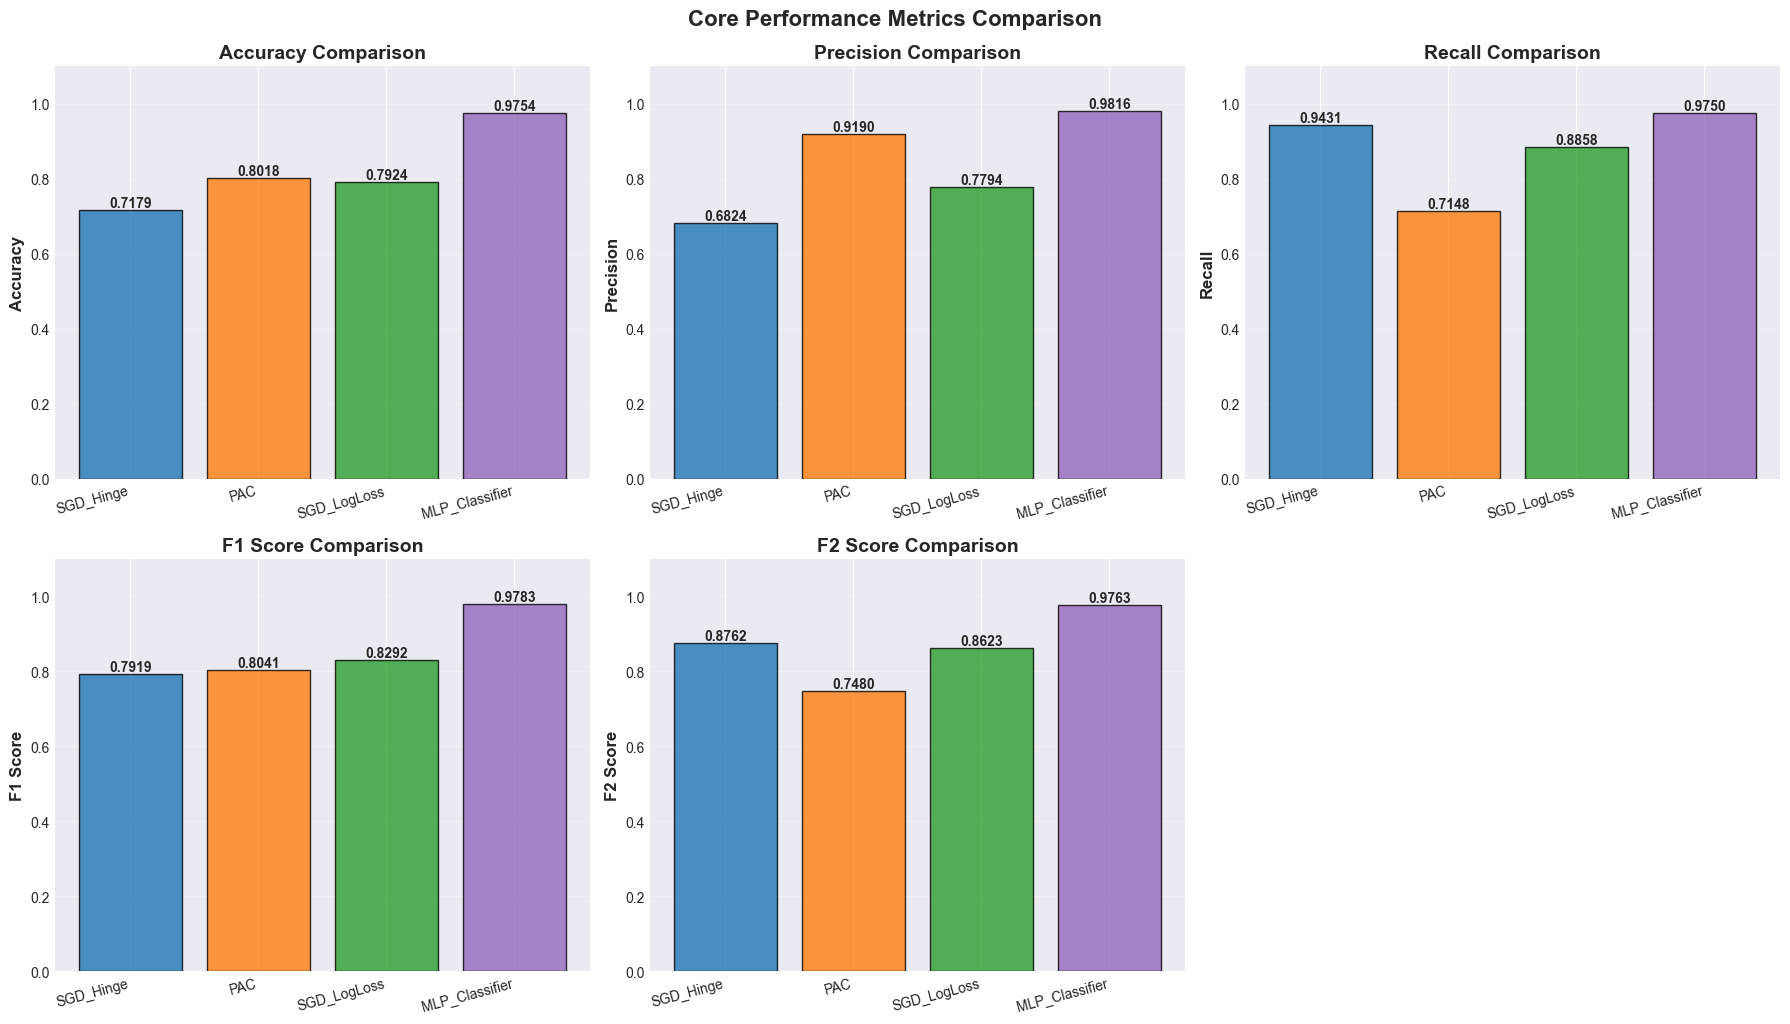


Core metrics visualization complete.


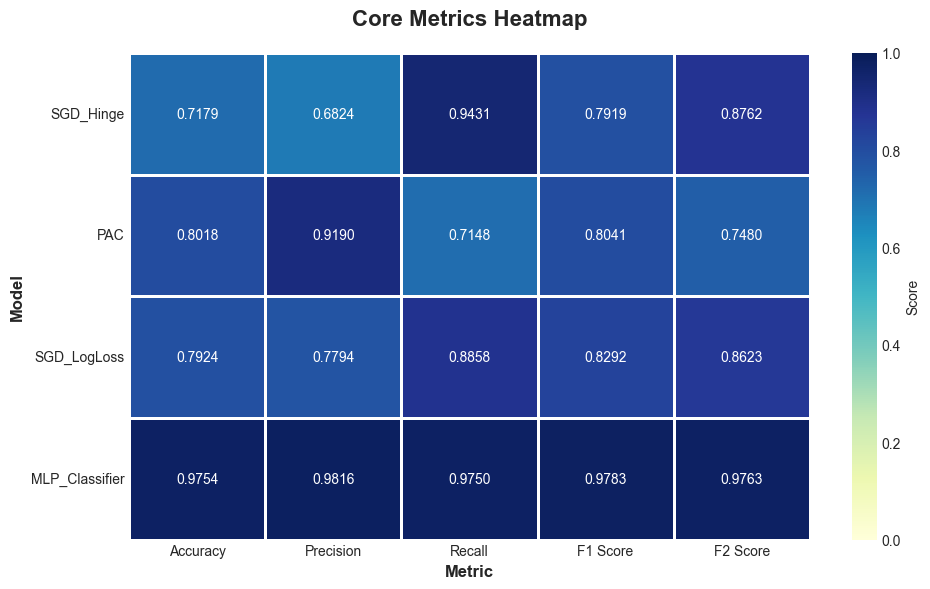


Core metrics heatmap complete.

[2/4] Evaluating Bias & Discrimination Metrics...

EVALUATING BIAS & DISCRIMINATION METRICS

Evaluating SGD_Hinge...
  ROC-AUC: 0.7967
  PR-AUC:  0.8454

Evaluating PAC...
  ROC-AUC: 0.8827
  PR-AUC:  0.9099

Evaluating SGD_LogLoss...
  ROC-AUC: 0.8474
  PR-AUC:  0.8749

Evaluating MLP_Classifier...
  ROC-AUC: 0.9942
  PR-AUC:  0.9938

BIAS METRICS SUMMARY
         Model  ROC_AUC   PR_AUC
     SGD_Hinge 0.796653 0.845361
           PAC 0.882728 0.909883
   SGD_LogLoss 0.847430 0.874867
MLP_Classifier 0.994177 0.993797

--------------------------------------------------------------------------------
Generating Bias Detection Visualizations...
--------------------------------------------------------------------------------


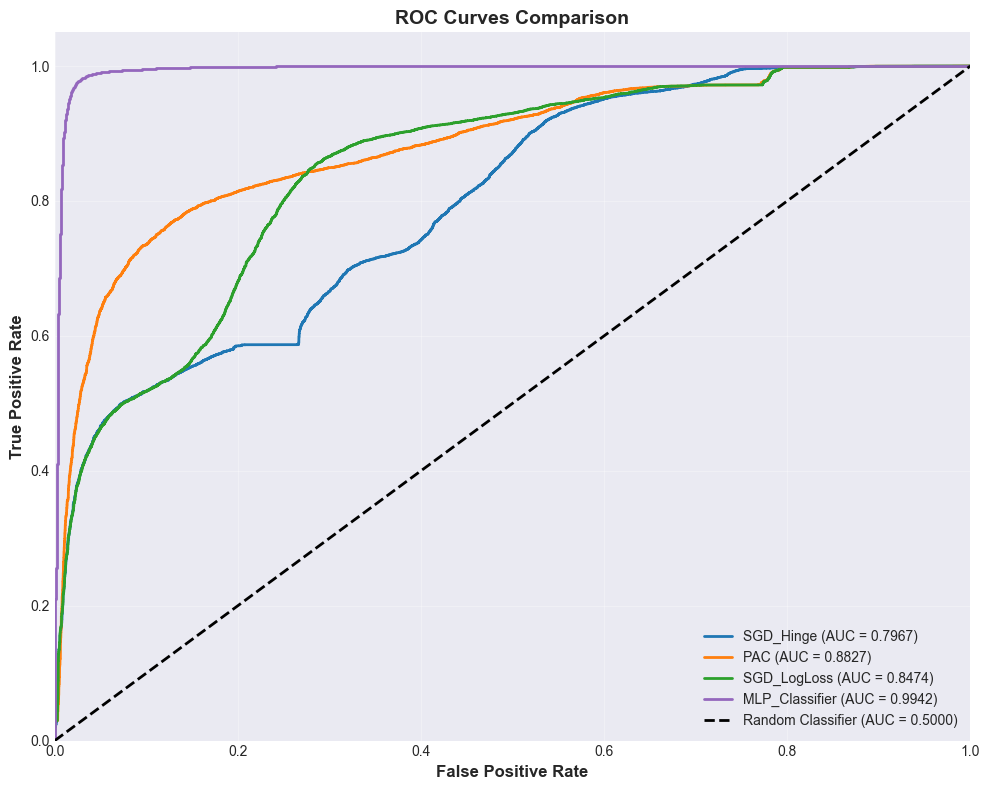


ROC curves visualization complete.


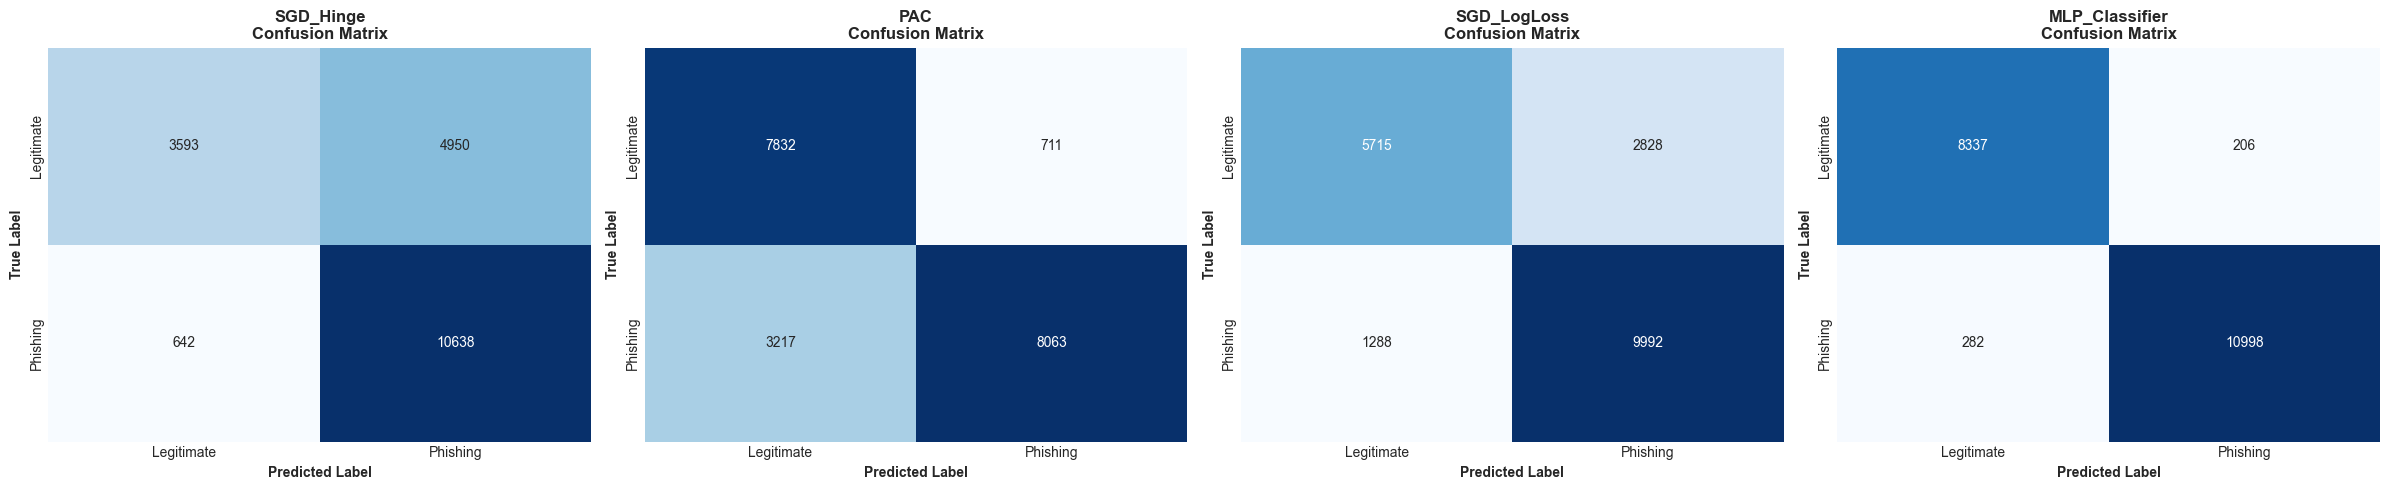


Confusion matrices visualization complete.


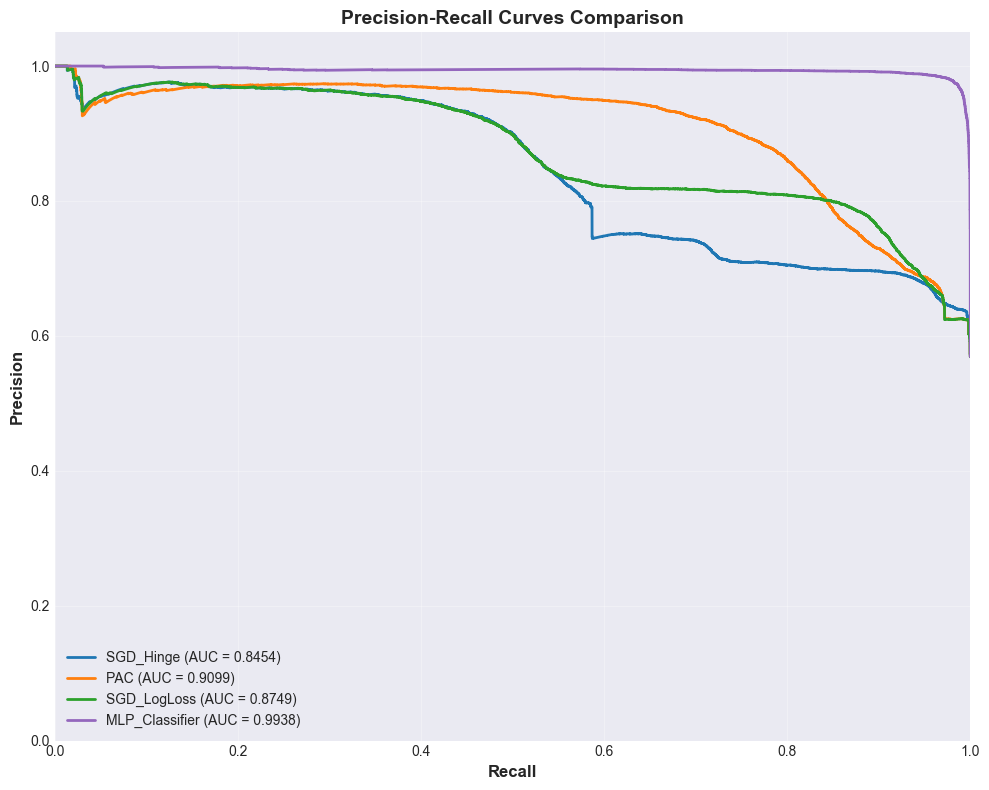


Precision-Recall curves visualization complete.

--------------------------------------------------------------------------------
Calculating Class-wise Metrics...
--------------------------------------------------------------------------------

CLASS-WISE METRICS

SGD_Hinge:
----------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.85      0.42      0.56      8543
    Phishing       0.68      0.94      0.79     11280

    accuracy                           0.72     19823
   macro avg       0.77      0.68      0.68     19823
weighted avg       0.75      0.72      0.69     19823


PAC:
----------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.71      0.92      0.80      8543
    Phishing       0.92      0.71      0.80     11280

    accuracy                           0.80     19823
   macro avg       0.81      0.82      0.80     19823
weighted avg       0.83      0.80  

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25084\3832558728.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(models, rotation=15, ha='right')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25084\3832558728.py:156: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(models, rotation=15, ha='right')


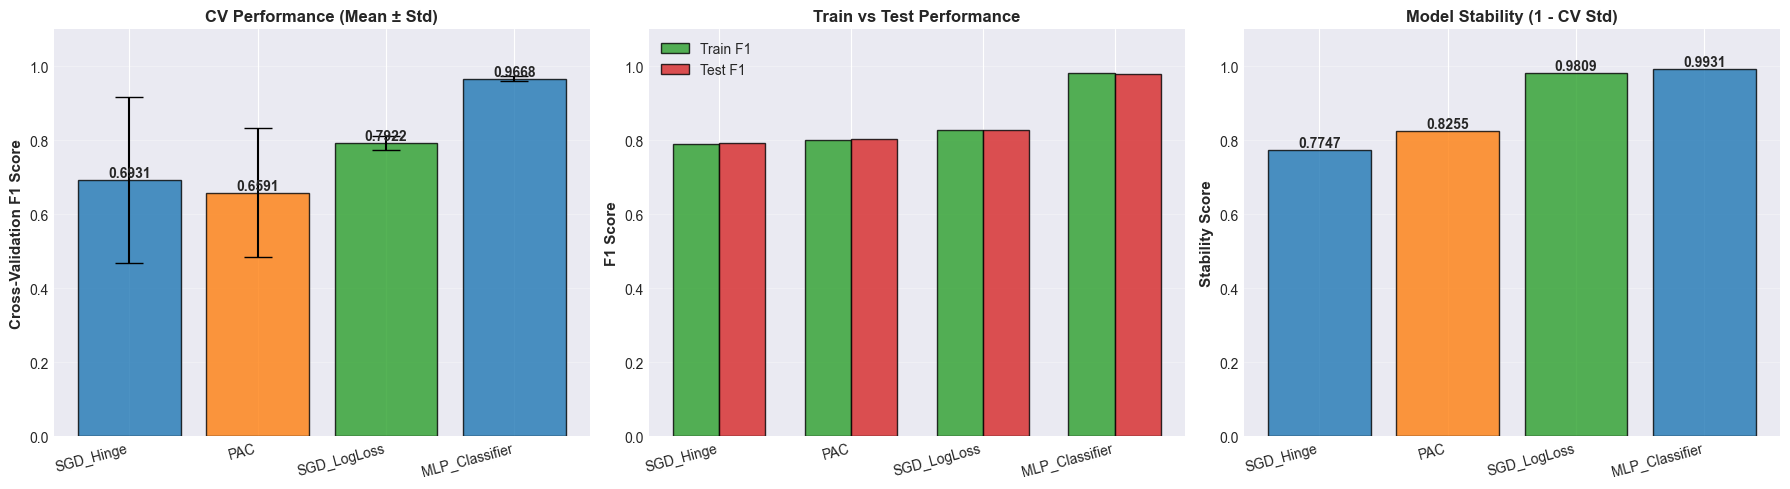


Robustness comparison visualization complete.

[4/4] Calculating Final Scores...

CALCULATING FINAL WEIGHTED SCORES

Weighting Scheme:
----------------------------------------
  Recall              : 35%
  F1_Score            : 25%
  ROC_AUC             : 20%
  Precision           : 10%
  Stability_Score     : 10%

FINAL SCORES & RANKINGS
         Model   Recall  F1_Score  Precision  ROC_AUC  Stability_Score  Final_Score  Rank
MLP_Classifier 0.975000  0.978296   0.981614 0.994177         0.993083     0.982129     1
   SGD_LogLoss 0.885816  0.829212   0.779407 0.847430         0.980906     0.862856     2
     SGD_Hinge 0.943085  0.791871   0.682448 0.796653         0.774705     0.833093     3
           PAC 0.714805  0.804129   0.918965 0.882728         0.825543     0.802210     4

--------------------------------------------------------------------------------
Generating Final Comparison Visualizations...
--------------------------------------------------------------------------------

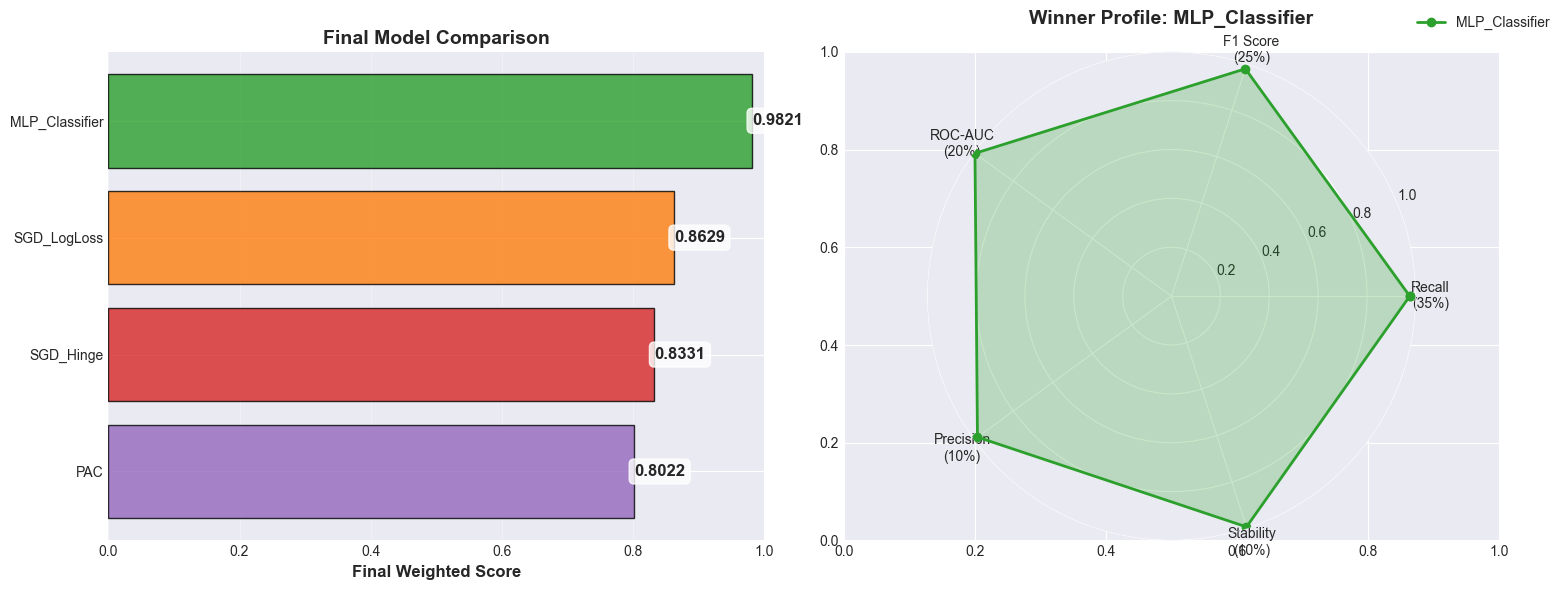


Final comparison visualization complete.


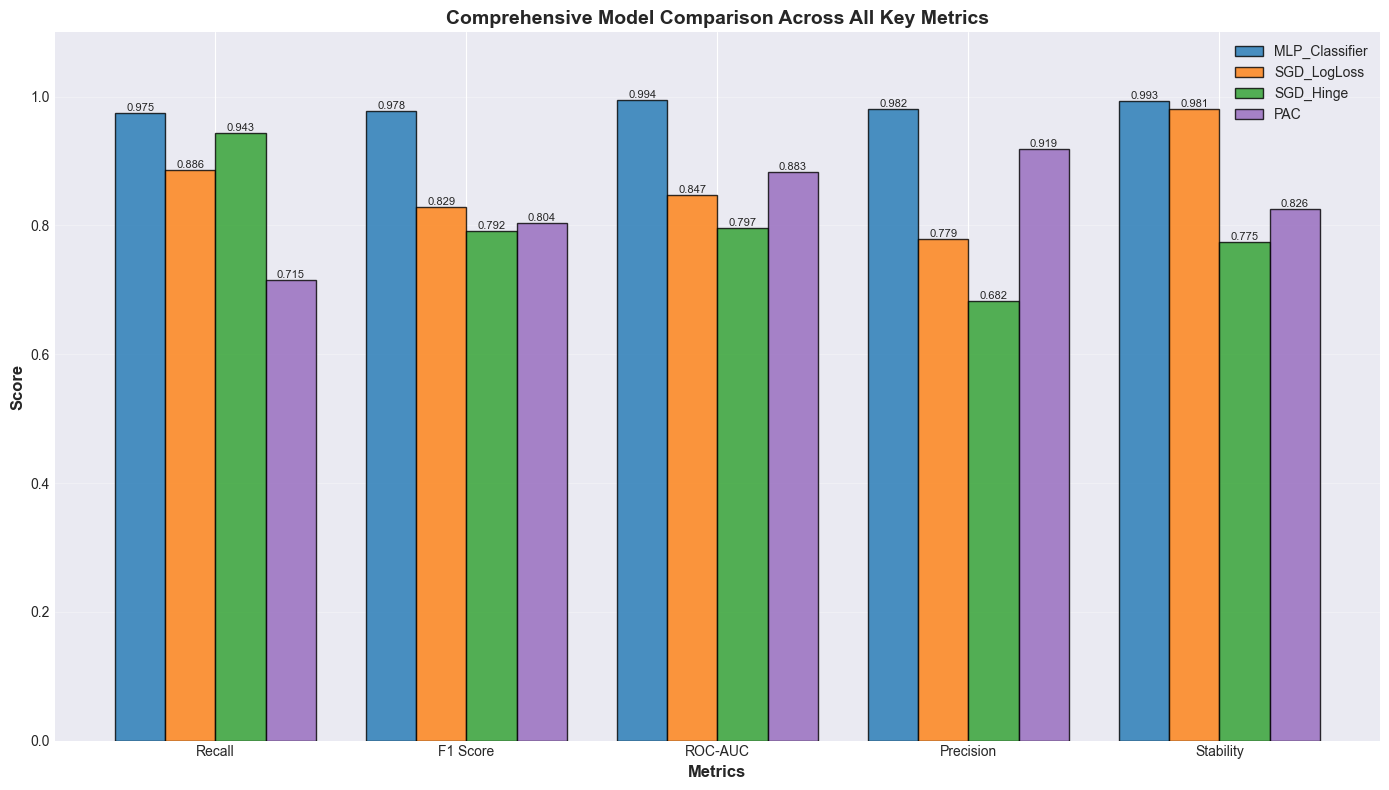


Comprehensive summary visualization complete.

WINNER DECLARATION

********************************************************************************
  WINNER: MLP_Classifier
  Final Score: 0.9821
********************************************************************************

MLP_Classifier Performance Summary:
--------------------------------------------------------------------------------

Core Metrics:
  Accuracy:  0.9754
  Precision: 0.9816
  Recall:    0.9750
  F1 Score:  0.9783
  F2 Score:  0.9763

Discrimination Metrics:
  ROC-AUC: 0.9942
  PR-AUC:  0.9938

Robustness Metrics:
  CV Mean F1:       0.9668
  CV Std Dev:       0.0069
  Performance Gap:  0.0027
  Stability Score:  0.9931

Key Strengths:
----------------------------------------
  1. Excellent recall - catches most phishing emails
  2. Excellent precision - minimal false alarms
  3. Outstanding balance between precision and recall
  4. Very stable performance across different data splits
  5. Excellent generalization 

In [21]:
# Evaluate Core Performance Metrics
print("\n[1/4] Evaluating Core Performance Metrics...")
core_results = evaluate_core_metrics(trained_models, X_test, y_test)

print("\n" + "-" * 80)
print("Generating Core Metrics Visualizations...")
print("-" * 80)
plot_core_metrics(core_results)
plot_metrics_heatmap(core_results)

# Evaluate Bias & Hallucination Detection
print("\n[2/4] Evaluating Bias & Discrimination Metrics...")
bias_results, predictions = evaluate_bias_metrics(trained_models, X_test, y_test)

print("\n" + "-" * 80)
print("Generating Bias Detection Visualizations...")
print("-" * 80)
plot_roc_curves(predictions)
plot_confusion_matrices(predictions)
plot_precision_recall_curves(predictions)

print("\n" + "-" * 80)
print("Calculating Class-wise Metrics...")
print("-" * 80)
classwise_results = calculate_classwise_metrics(predictions)

# Evaluate Robustness
print("\n[3/4] Evaluating Model Robustness...")
robustness_results = evaluate_robustness(trained_models, X_train, y_train, X_test, y_test)

print("\n" + "-" * 80)
print("Generating Robustness Visualizations...")
print("-" * 80)
plot_robustness_comparison(robustness_results)

# Calculate Final Scores and Declare Winner
print("\n[4/4] Calculating Final Scores...")
final_results = calculate_final_scores(core_results, bias_results, robustness_results)

print("\n" + "-" * 80)
print("Generating Final Comparison Visualizations...")
print("-" * 80)
plot_final_comparison(final_results)
plot_comprehensive_summary(final_results, core_results)

# Declare Winner
declare_winner(final_results, core_results, bias_results, robustness_results)

#### STEP 10: SUMMARY REPORT & EXPORT

In [22]:
# Get winner information
winner = final_results.iloc[0]
winner_name = winner['Model']
winner_score = winner['Final_Score']

print("\n" + "=" * 80)
print("PHISHING EMAIL DETECTION - MODEL EVALUATION SUMMARY")
print("=" * 80)

print(f"\nEvaluation Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Dataset: {X_train.shape[0] + X_test.shape[0]:,} total samples")
print(f"Training Set: {X_train.shape[0]:,} samples")
print(f"Test Set: {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]:,} (TF-IDF + Engineered)")

print("\n" + "-" * 80)
print("MODELS EVALUATED")
print("-" * 80)
for i, model_name in enumerate(trained_models.keys(), 1):
    print(f"{i}. {model_name}")
    print(f"   Training Time: {training_times[model_name]:.2f} seconds")

print("\n" + "-" * 80)
print("EVALUATION METRICS USED")
print("-" * 80)
print("Core Performance:")
print("  - Accuracy, Precision, Recall, F1 Score, F2 Score")
print("\nBias & Discrimination:")
print("  - ROC-AUC, Precision-Recall AUC, Confusion Matrix, Class-wise Metrics")
print("\nRobustness:")
print("  - 5-Fold Cross-Validation, Training vs Test Gap, Stability Score")

print("\n" + "-" * 80)
print("FINAL RANKINGS")
print("-" * 80)
for idx, row in final_results.iterrows():
    rank_symbol = "★" if row['Rank'] == 1 else " "
    print(f"{rank_symbol} Rank {row['Rank']}: {row['Model']:20s} - Score: {row['Final_Score']:.4f}")

print("\n" + "=" * 80)
print(f"RECOMMENDED MODEL: {winner_name}")
print("=" * 80)

winner_core = core_results[core_results['Model'] == winner_name].iloc[0]
winner_bias = bias_results[bias_results['Model'] == winner_name].iloc[0]
winner_robust = robustness_results[robustness_results['Model'] == winner_name].iloc[0]

print(f"\nFinal Score: {winner_score:.4f}")
print("\nKey Performance Indicators:")
print(f"Recall (Phishing Detection Rate): {winner_core['Recall']*100:.2f}%")
print(f"Precision (Accuracy of Alerts):   {winner_core['Precision']*100:.2f}%")
print(f"F1 Score (Overall Balance):       {winner_core['F1_Score']:.4f}")
print(f"ROC-AUC (Discrimination):          {winner_bias['ROC_AUC']:.4f}")
print(f"Stability (Consistency):           {winner_robust['Stability_Score']:.4f}")

os.makedirs('results', exist_ok=True)

# Export all results
core_results.to_csv('results/core_metrics.csv', index=False)
bias_results.to_csv('results/bias_metrics.csv', index=False)
robustness_results.to_csv('results/robustness_metrics.csv', index=False)
final_results.to_csv('results/final_rankings.csv', index=False)
classwise_results.to_csv('results/classwise_metrics.csv', index=False)


PHISHING EMAIL DETECTION - MODEL EVALUATION SUMMARY

Evaluation Date: 2025-11-22 20:47:20
Dataset: 99,115 total samples
Training Set: 79,292 samples
Test Set: 19,823 samples
Features: 7,015 (TF-IDF + Engineered)

--------------------------------------------------------------------------------
MODELS EVALUATED
--------------------------------------------------------------------------------
1. SGD_Hinge
   Training Time: 394.32 seconds
2. PAC
   Training Time: 38.05 seconds
3. SGD_LogLoss
   Training Time: 325.34 seconds
4. MLP_Classifier
   Training Time: 970.89 seconds

--------------------------------------------------------------------------------
EVALUATION METRICS USED
--------------------------------------------------------------------------------
Core Performance:
  - Accuracy, Precision, Recall, F1 Score, F2 Score

Bias & Discrimination:
  - ROC-AUC, Precision-Recall AUC, Confusion Matrix, Class-wise Metrics

Robustness:
  - 5-Fold Cross-Validation, Training vs Test Gap, Stabil

#### EXPORT WINNING MODEL

In [23]:
# Create export directory
export_dir = 'models/production'
os.makedirs(export_dir, exist_ok=True)

print(f"\nExport directory created: {export_dir}/")

# ============================================================================
# DYNAMICALLY GET THE WINNER FROM FINAL RESULTS
# ============================================================================
winner_name = final_results.iloc[0]['Model']  # Get top-ranked model
production_model = trained_models[winner_name]

print(f"\n{'='*80}")
print(f"EXPORTING WINNER: {winner_name}")
print(f"{'='*80}")

# Get winner metrics from evaluation results
winner_core = core_results[core_results['Model'] == winner_name].iloc[0]
winner_bias = bias_results[bias_results['Model'] == winner_name].iloc[0]
winner_robust = robustness_results[robustness_results['Model'] == winner_name].iloc[0]
winner_final = final_results[final_results['Model'] == winner_name].iloc[0]

# Export model as pickle file
model_filename = f"{export_dir}/phishing_detector_{winner_name.lower()}.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(production_model, f)

print(f"\n[1/3] Model exported: {model_filename}")

# Determine model type description
model_type_map = {
    'SGD_Hinge': 'SGDClassifier with hinge loss (Linear SVM)',
    'PAC': 'Passive Aggressive Classifier',
    'SGD_LogLoss': 'SGDClassifier with log_loss (Logistic Regression)',
    'MLP_Classifier': 'Multi-Layer Perceptron Neural Network'
}

# Create model metadata
metadata = {
    'model_info': {
        'model_name': winner_name,
        'model_type': model_type_map.get(winner_name, 'Unknown'),
        'final_score': float(winner_final['Final_Score']),
        'rank': int(winner_final['Rank']),
        'export_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'tuning_applied': False,
        'notes': f'{winner_name} selected as winner based on comprehensive evaluation'
    },
    'performance_metrics': {
        'accuracy': float(winner_core['Accuracy']),
        'precision': float(winner_core['Precision']),
        'recall': float(winner_core['Recall']),
        'f1_score': float(winner_core['F1_Score']),
        'f2_score': float(winner_core['F2_Score']),
        'roc_auc': float(winner_bias['ROC_AUC']),
        'pr_auc': float(winner_bias['PR_AUC'])
    },
    'robustness_metrics': {
        'cv_mean_f1': float(winner_robust['CV_Mean_F1']),
        'cv_std_dev': float(winner_robust['CV_Std_Dev']),
        'stability_score': float(winner_robust['Stability_Score']),
        'performance_gap': float(winner_robust['Performance_Gap'])
    },
    'hyperparameters': {k: str(v) for k, v in production_model.get_params().items()},
    'training_info': {
        'dataset_size': int(X_train.shape[0] + X_test.shape[0]),
        'training_samples': int(X_train.shape[0]),
        'test_samples': int(X_test.shape[0]),
        'num_features': int(X_train.shape[1]),
        'tuning_method': 'None - Base Model',
        'tuning_time_minutes': 0.0,
        'training_time_seconds': float(training_times.get(winner_name, 0))
    },
    'competition_results': {
        'total_models_evaluated': len(final_results),
        'all_models': final_results['Model'].tolist(),
        'all_scores': final_results['Final_Score'].tolist(),
        'all_ranks': final_results['Rank'].tolist()
    }
}

metadata_filename = f"{export_dir}/model_metadata.json"
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"[2/3] Metadata exported: {metadata_filename}")

# Create a summary report
summary_filename = f"{export_dir}/winner_summary.txt"
with open(summary_filename, 'w') as f:
    f.write("="*80 + "\n")
    f.write("PHISHING DETECTION MODEL - WINNER EXPORT SUMMARY\n")
    f.write("="*80 + "\n\n")

    f.write(f"Winner: {winner_name}\n")
    f.write(f"Model Type: {model_type_map.get(winner_name, 'Unknown')}\n")
    f.write(f"Final Score: {winner_final['Final_Score']:.4f}\n")
    f.write(f"Export Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    f.write("Performance Metrics:\n")
    f.write("-"*40 + "\n")
    f.write(f"  Accuracy:  {winner_core['Accuracy']:.4f}\n")
    f.write(f"  Precision: {winner_core['Precision']:.4f}\n")
    f.write(f"  Recall:    {winner_core['Recall']:.4f}\n")
    f.write(f"  F1 Score:  {winner_core['F1_Score']:.4f}\n")
    f.write(f"  ROC-AUC:   {winner_bias['ROC_AUC']:.4f}\n\n")

    f.write("Competition Results:\n")
    f.write("-"*40 + "\n")
    for idx, row in final_results.iterrows():
        f.write(f"  {row['Rank']}. {row['Model']}: {row['Final_Score']:.4f}\n")

print(f"[3/3] Summary exported: {summary_filename}")

print(f"\n{'='*80}")
print("EXPORT COMPLETE!")
print(f"{'='*80}")
print(f"\nFiles created:")
print(f"  1. {model_filename}")
print(f"  2. {metadata_filename}")
print(f"  3. {summary_filename}")


Export directory created: models/production/

EXPORTING WINNER: MLP_Classifier

[1/3] Model exported: models/production/phishing_detector_mlp_classifier.pkl
[2/3] Metadata exported: models/production/model_metadata.json
[3/3] Summary exported: models/production/winner_summary.txt

EXPORT COMPLETE!

Files created:
  1. models/production/phishing_detector_mlp_classifier.pkl
  2. models/production/model_metadata.json
  3. models/production/winner_summary.txt
